# **10Alytics Hackathon 2025**

## **Background & Problem Statement**

### **Background**

Across many developing economies — including Nigeria and other African countries — fiscal, economic, and demographic data are under-utilized in policymaking. Governments collect large volumes of information on budgets, GDP, trade, taxation, health and population dynamics, yet these datasets are often fragmented, not integrated, and rarely translated into actionable insights. The result: inefficient public spending, weak revenue mobilization, rising inflation, persistent unemployment, and widening inequality — all of which hinder sustainable development.

### **Problem Statement**

This hackathon challenges participants to use **AI, data science, and analytical modelling** to transform fragmented macroeconomic and fiscal indicators — including **Budget Balance, Capital and Health Expenditure, Nominal vs Real GDP, Inflation, VAT, Trade Data, Unemployment, Government Debt, and Population metrics** — into meaningful intelligence that strengthens governance, supports inclusive growth, and drives evidence-based policy choices. By connecting these datasets to measurable development outcomes, solutions should directly advance the Sustainable Development Goals (SDGs) and produce policy-ready recommendations for governments and development partners.

---

### **Objective**

**Primary objective:** Use the provided fiscal and macroeconomic datasets to identify meaningful patterns, detect fiscal risks, forecast future fiscal performance, and develop evidence-backed strategies that improve fiscal resilience and promote sustainable, inclusive development.

---

### **Expected Outcomes**

* **Visualizations** that illustrate historical trends in government budget deficits and surpluses across countries.
* **Identification of key drivers** of fiscal instability (e.g., revenue volatility, expenditure growth, shocks).
* **Anomaly & risk detection** using quantitative methods to highlight countries/periods of concern.
* **Predictive models** that forecast near-term fiscal performance or identify countries at elevated financial risk.
* **Actionable, policy-ready recommendations** to strengthen fiscal resilience, improve budget discipline, and support evidence-based policymaking.
* **A clear presentation** of insights tailored to decision-makers, development institutions, and economic researchers.

---

### **SDG Alignment (Direct Links)**

The analysis should tie findings and recommendations to the following Sustainable Development Goals:

* **SDG 1 & 2 (No Poverty; Zero Hunger):** Use income, inflation, food price, and unemployment analysis to inform anti-poverty and food security interventions.
* **SDG 3 (Good Health & Well-being):** Link health expenditure, population, and real GDP to assess health system performance and financing gaps.
* **SDG 4 (Quality Education):** Use revenue and expenditure patterns to evaluate education financing and equity.
* **SDG 8 (Decent Work & Economic Growth):** Leverage GDP growth, unemployment, tax revenue, and trade data to promote jobs and sustainable growth.
* **SDG 9 (Industry, Innovation & Infrastructure):** Analyse capital expenditure and government debt to inform infrastructure planning and investment prioritization.
* **SDG 10 (Reduced Inequalities):** Use fiscal insights to propose progressive, transparent resource allocations that address inequality.
* **SDG 16 (Peace, Justice & Strong Institutions):** Improve public finance transparency and accountability through data-driven governance tools.

---

### **Key Research Questions**

1. **Trend identification:** How have budget balances, revenues, and expenditures evolved over time across countries in the dataset?
2. **Drivers:** Which macroeconomic and fiscal indicators are most strongly associated with fiscal stress (deficits, rising debt)?
3. **Anomalies & risk:** Which country-years show anomalous fiscal behavior, and what likely shocks or policy changes coincide with those anomalies?
4. **Forecasting:** What are short- to medium-term forecasts for budget balance and debt trajectories under baseline and shock scenarios?
5. **Policy levers:** Which actionable fiscal policy measures (revenue mobilization, expenditure reprioritization, stabilization mechanisms) are most likely to reduce near-term fiscal vulnerability while protecting SDG progress?
6. **Equity & impact:** How would proposed fiscal adjustments likely affect vulnerable populations and SDG outcomes?

---

### **Definitions (Data Dictionary - key fields)**

* **Country:** Country name for each fiscal observation.
* **Indicator:** Specific fiscal or economic metric (e.g., Revenue, Expenditure, Budget Balance).
* **Source:** Data provider (institution or organization).
* **Unit:** Measurement unit for amounts reported.
* **Currency:** National currency used for monetary fields.
* **Frequency:** Reporting frequency (annual, quarterly, etc.).
* **Country Code:** Standard three-letter country code (ISO3).
* **Time:** Date or period of the observation (timestamp).
* **Amount:** Numerical value of the fiscal indicator for the given country and time period.


#### **1. Loading the Fiscal Dataset**

In this first step, we begin by importing the essential Python libraries and loading the dataset  
**10Alytics_Fiscal_Data.csv** into a pandas DataFrame.  
This establishes the foundation for all subsequent data exploration, transformation, and modelling.  
A quick preview (`df.head()`) will help us confirm the structure, spot obvious issues,  
and verify that the import was successful.

The cell below loads the dataset and prints the first five rows.


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("10Alytics_Fiscal_Data.csv")

# Preview the data structure
df.head()

,Country,Indicator,Source,Unit,Currency,Frequency,Country Code,Time,Amount
0,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2007-01-01,-56213
1,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2008-01-01,-67563
2,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2009-01-01,-72379
3,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2010-01-01,-98886
4,Egypt,Budget Deficit/Surplus,Central Bank of Egypt,Million,EGP,Yearly,EGY,2011-01-01,-134138


## **2. Understanding the Data Structure**

Before any cleaning or modelling is done, it is essential to understand:
- What columns exist  
- Their data types  
- Whether numerical columns loaded correctly  
- The presence of missing values  
- Basic metadata (number of rows, columns)

In [6]:
# Summary of dataset structure
print("Dataset Shape:", df.shape)

Dataset Shape: (23784, 9)


In [7]:
print("\nColumn Data Types:")
print(df.dtypes)


Column Data Types:
Country         object
Indicator       object
Source          object
Unit            object
Currency        object
Frequency       object
Country Code    object
Time            object
Amount          object
dtype: object


In [5]:
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
Country             0
Indicator           0
Source              0
Unit               22
Currency        10503
Frequency           0
Country Code        0
Time                4
Amount             59
dtype: int64


In [8]:
print("Statistical Summary:")
print(df.describe(include='all'))

Statistical Summary:
             Country        Indicator                               Source  \
count          23784            23784                                23784   
unique            14               27                                   28   
top     South Africa  Inflation Rate   Central Bank of West African States   
freq            5108             2879                                 3295   

           Unit Currency Frequency Country Code        Time Amount  
count     23762    13281     23784        23784       23780  23725  
unique       10       13         3           14        1070  15126  
top     Million      ZAR   Monthly          ZAF  2021-01-01     12  
freq       9964     3086     16850         5108         246    222  


## 3. Converting Data Types for Accurate Analysis

The initial inspection shows that several important fields — notably **Time** and **Amount** — were loaded as `object` type.  
For meaningful time-series analysis, modelling, and numerical computation, these fields must be correctly converted.

### Why this step is important:
- **Time** must be parsed as a proper datetime field to enable resampling, sorting, and trend analysis.  
- **Amount** must be numeric; otherwise, aggregations, correlations, comparisons, or forecasts will be impossible.  
- Ensuring proper data types at this stage prevents errors in later modelling steps and improves overall data reliability.

The following cell:
1. Converts the `time` column to datetime  
2. Converts `amount` to numeric (coercing invalid entries to NaN)  
3. Rechecks the data types to confirm successful conversion  
4. Displays problematic rows (if any), helping us identify inconsistencies in the raw data

In [9]:
# Convert `time` column to datetime format
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

# Convert `amount` column to numeric
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

In [10]:
# Confirm the conversions
print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
Country                 object
Indicator               object
Source                  object
Unit                    object
Currency                object
Frequency               object
Country Code            object
Time            datetime64[ns]
Amount                 float64
dtype: object


In [11]:
# Optional: Show rows where conversion resulted in NaT or NaN
invalid_time = df[df['Time'].isna()]
invalid_amount = df[df['Amount'].isna()]

print("\nRows with invalid Time formats:", len(invalid_time))
print("Rows with invalid Amount values:", len(invalid_amount))


Rows with invalid Time formats: 4
Rows with invalid Amount values: 502


In [12]:
df.Frequency.unique()

array(['Yearly', 'Monthly', 'Quarterly'], dtype=object)

## 4. Overview: What Economic & Fiscal Indicators Do We Have?

Before deep analysis, it is important to understand the scope of the dataset —  
specifically, the **unique fiscal indicators** available.  
This helps shape which SDGs each indicator maps to, what insights are possible,  
and what modelling directions make sense (e.g., forecasting, clustering, anomaly detection).

In [14]:
# Inspect unique indicators
print(df['Indicator'].value_counts())

Indicator
Inflation Rate                2879
Consumer Price Index (CPI)    2850
Interest Rate                 2652
Revenue                       1752
Exports                       1611
Imports                       1590
Budget Deficit/Surplus        1417
Government Debt               1121
Food Inflation                1069
Nominal GDP                   1008
Real GDP                      1001
GDP Growth Rate                962
Expenditure                    961
Tax Revenue                    762
Capital Expenditure            663
Value Added Tax (VAT)          376
Population                     323
Unemployment Rate              218
Defence Expenditure            140
Labour Force                   132
Inflation Rate                 124
Health Expenditure              43
GDP per Capita                  41
GDP per Capita                  30
Food Inflation YoY              30
Education Expenditure           19
GDP per capita                  10
Name: count, dtype: int64


### Indicator Exploration and Data Quality Check

A preliminary review of the `Indicator` column reveals significant variation in the 
number of observations across fiscal and macroeconomic variables. High-frequency 
indicators such as *Inflation Rate, CPI, and Interest Rate* account for over 2,000 
entries each, while essential development indicators such as *Education Expenditure* 
and *Health Expenditure* appear fewer than 50 times.

This imbalance suggests differences in reporting frequency across countries and years, 
but it also highlights potential data quality issues. Several indicators appear under 
multiple names (e.g., "GDP per Capita", "GDP per capita", and versions with trailing 
spaces). These inconsistencies can fragment analysis, distort grouping operations, and 
reduce the reliability of insights.

To ensure analytical integrity, the next steps will involve:

1. **Standardizing indicator names** (lowercasing, trimming spaces, harmonizing variants).  
2. **Handling sparse indicators** appropriately to avoid biased conclusions.  
3. **Segmenting data by reporting frequency** (Yearly, Quarterly, Monthly) to maintain 
   valid time-series trends.

This systematic cleaning process will ensure that subsequent analysis, modeling, and policy 
insights are based on consistent and reliable metrics.

In [17]:
# Inspect raw unique names
sorted(df['Indicator'].unique())

# Clean indicators: lowercase + strip whitespace
df['Indicator_clean'] = df['Indicator'].str.lower().str.strip()

# Optional: manually unify known duplicates
replace_map = {
    'gdp per capita': 'gdp_per_capita',
    'gdp per capita ': 'gdp_per_capita',
    'gdp per capita (usd)': 'gdp_per_capita',
}

df['Indicator_clean'] = df['Indicator_clean'].replace(replace_map)

print(df['Indicator_clean'].value_counts().head)


<bound method NDFrame.head of Indicator_clean
inflation rate                3003
consumer price index (cpi)    2850
interest rate                 2652
revenue                       1752
exports                       1611
imports                       1590
budget deficit/surplus        1417
government debt               1121
food inflation                1069
nominal gdp                   1008
real gdp                      1001
gdp growth rate                962
expenditure                    961
tax revenue                    762
capital expenditure            663
value added tax (vat)          376
population                     323
unemployment rate              218
defence expenditure            140
labour force                   132
gdp_per_capita                  81
health expenditure              43
food inflation yoy              30
education expenditure           19
Name: count, dtype: int64>


In [18]:
# 1. Clean 'Amount' and 'Time' columns
df['Amount'] = df['Amount'].astype(str).str.replace(',', '', regex=False)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
df['Year'] = df['Time'].dt.year

# Drop rows where core variables are missing (Time, Amount)
df.dropna(subset=['Time', 'Amount'], inplace=True)

# Now, handle the remaining missing values
initial_rows_after_core_drop = len(df)
df.dropna(subset=['Unit'], inplace=True)
print(f"Rows dropped due to missing 'Unit': {initial_rows_after_core_drop - len(df)}")
print(f"Rows remaining after dropping missing 'Unit': {len(df)}")

Rows dropped due to missing 'Unit': 0
Rows remaining after dropping missing 'Unit': 23278


In [19]:
# 2. Handle missing 'Currency' (approx. 10,000 rows missing): Impute based on Country Code.
# Missing currency often means the indicator is a percentage (like Inflation Rate) or unit-less.
# We will impute the currency based on the most frequent currency for that country code.

# Create a mapping of Country Code to the most frequent Currency used in that country.
currency_map = df.groupby('Country Code')['Currency'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)

# Fill missing Currency values using the mapped mode currency for that Country Code
df['Currency'] = df.apply(
    lambda row: currency_map[row['Country Code']] if pd.isnull(row['Currency']) else row['Currency'],
    axis=1
)

# Fill any remaining NaNs in Currency (should be zero now) with a generic 'N/A' for safety.
df['Currency'].fillna('N/A', inplace=True)

print(f"Missing 'Currency' after imputation: {df['Currency'].isnull().sum()}")

Missing 'Currency' after imputation: 0


C:\Users\Edwin George\AppData\Local\Temp\ipykernel_16228\4222136291.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Currency'].fillna('N/A', inplace=True)


In [20]:
print("\nMissing Values:")
print(df.isna().sum())


Missing Values:
Country            0
Indicator          0
Source             0
Unit               0
Currency           0
Frequency          0
Country Code       0
Time               0
Amount             0
Indicator_clean    0
Year               0
dtype: int64


In [21]:
# --- Structuring for Panel Data (Pivoting) ---

# Pivot the data to create the Panel Data structure
df_panel = df.pivot_table(
    index=['Country', 'Country Code', 'Time', 'Year', 'Frequency', 'Currency'],
    columns='Indicator',
    values='Amount',
    aggfunc='first'
).reset_index()

# Clean up column names for easier code use (e.g., remove spaces and special characters)
df_panel.columns.name = None
df_panel.columns = [
    col.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_').replace('.', '_').replace('-', '_')
    for col in df_panel.columns
]

# Display the new structure
print("\n--- Panel Data Structure (Wide Format) ---")
print(f"New DataFrame Shape: {df_panel.shape}")
print("\nNew Columns (A Wide Panel Data Set):")
print(df_panel.columns.tolist())


--- Panel Data Structure (Wide Format) ---
New DataFrame Shape: (6159, 32)

New Columns (A Wide Panel Data Set):
['Country', 'Country_Code', 'Time', 'Year', 'Frequency', 'Currency', 'Budget_Deficit_Surplus', 'Capital_Expenditure', 'Consumer_Price_Index_CPI', 'Defence_Expenditure', 'Education_Expenditure', 'Expenditure', 'Exports', 'Food_Inflation_', 'Food_Inflation_YoY', 'GDP_Growth_Rate', 'GDP_per_Capita', 'GDP_per_Capita_', 'Government_Debt', 'Health_Expenditure', 'Imports', 'Inflation_Rate', 'Inflation_Rate_', 'Interest_Rate', 'Labour_Force', 'Nominal_GDP', 'Population', 'Real_GDP', 'Revenue', 'Tax_Revenue', 'Unemployment_Rate', 'Value_Added_Tax_VAT']


In [23]:
# Write to CSV for the user to download the prepared data
df_panel.to_csv('10Alytics_Fiscal_Panel_Data.csv', index=False)

print("\n(Panel data saved to 10Alytics_Fiscal_Panel_Data.csv)")
print("\nPanel Data Head:")
df_panel.head()


(Panel data saved to 10Alytics_Fiscal_Panel_Data.csv)

Panel Data Head:


,Country,Country_Code,Time,Year,Frequency,Currency,Budget_Deficit_Surplus,Capital_Expenditure,Consumer_Price_Index_CPI,Defence_Expenditure,...,Inflation_Rate_,Interest_Rate,Labour_Force,Nominal_GDP,Population,Real_GDP,Revenue,Tax_Revenue,Unemployment_Rate,Value_Added_Tax_VAT
0,Algeria,DZA,1977-01-01,1977.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Algeria,DZA,1978-01-01,1978.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Algeria,DZA,1979-01-01,1979.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Algeria,DZA,1980-01-01,1980.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Algeria,DZA,1981-01-01,1981.0,Yearly,USD,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
print("\nMissing Values:")
print(df_panel.isna().sum())


Missing Values:
Country                        0
Country_Code                   0
Time                           0
Year                           0
Frequency                      0
Currency                       0
Budget_Deficit_Surplus      4763
Capital_Expenditure         5496
Consumer_Price_Index_CPI    3316
Defence_Expenditure         6040
Education_Expenditure       6140
Expenditure                 5219
Exports                     4639
Food_Inflation_             5107
Food_Inflation_YoY          6129
GDP_Growth_Rate             5197
GDP_per_Capita              6140
GDP_per_Capita_             6129
Government_Debt             5038
Health_Expenditure          6116
Imports                     4647
Inflation_Rate              6035
Inflation_Rate_             3291
Interest_Rate               3511
Labour_Force                6030
Nominal_GDP                 5173
Population                  5976
Real_GDP                    5235
Revenue                     4428
Tax_Revenue               

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned Panel Data
file_path = '10Alytics_Fiscal_Panel_Data.csv'
df_panel = pd.read_csv(file_path)


# Define the final cleaned column names
BUDGET_COL = 'Budget_Deficit_Surplus'
DEBT_COL = 'Government_Debt'
INFLATION_COL = 'Inflation_Rate_' # The column with fewer missing values was selected

top_countries = ['South Africa', 'Nigeria', 'Ghana', 'Egypt', 'Kenya']
df_plot = df_panel[df_panel['Country'].isin(top_countries) & (df_panel['Year'] >= 1990)]

# --- Step 3A & 3B: Trend Visualization ---
# Plot 1: Fiscal Stability Trends (Budget & Debt) - saved to fiscal_stability_trends.png
# Plot 2: Inflation Rate Trends (Social/Economic Risk) - saved to inflation_trends.png



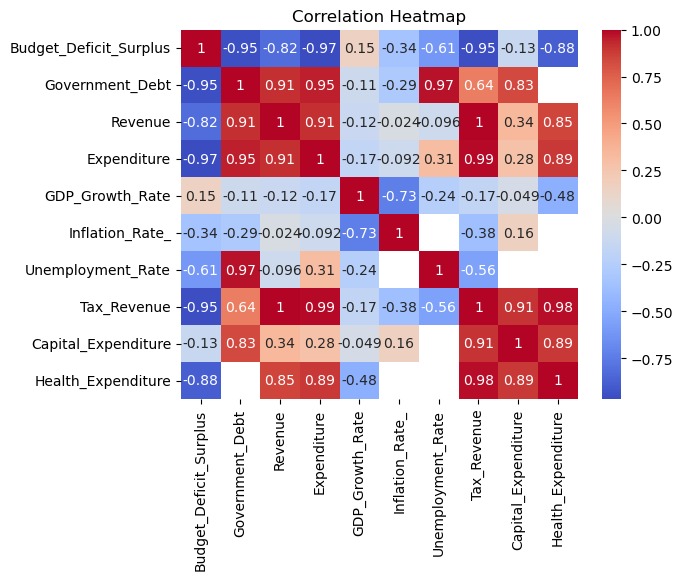

In [27]:
# --- Step 4: Initial Driver Analysis (Correlation) ---
core_variables = [
    BUDGET_COL, DEBT_COL, 'Revenue', 'Expenditure', 'GDP_Growth_Rate', 
    INFLATION_COL, 'Unemployment_Rate', 'Tax_Revenue', 'Capital_Expenditure', 
    'Health_Expenditure'
]
# Calculate and plot the correlation matrix - saved to correlation_heatmap.png
correlation_matrix = df_panel[core_variables].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the cleaned Panel Data
file_path = '10Alytics_Fiscal_Panel_Data.csv'
df_panel = pd.read_csv(file_path)

# --- Initial Data Cleaning and Selection for EDA ---

# 1. Handle Duplicate Columns (Select the one with fewer NaNs)
def select_cleanest_column(df, prefixes):
    """Finds the column among duplicates with the fewest NaNs."""
    best_col = None
    min_na = float('inf')
    
    # Identify all columns related to the prefixes
    related_cols = [col for col in df.columns if any(col.startswith(p) for p in prefixes)]
    
    if not related_cols:
        return None, None

    for col in related_cols:
        na_count = df[col].isnull().sum()
        if na_count < min_na:
            min_na = na_count
            best_col = col
    
    # Drop all related columns except the best one
    cols_to_drop = [col for col in related_cols if col != best_col]
    df.drop(columns=cols_to_drop, inplace=True)
    return best_col, related_cols

# Consolidate Inflation Rate
inflation_col, _ = select_cleanest_column(df_panel, ['Inflation_Rate', 'Inflation_Rate_'])
print(f"Selected Inflation Column: {inflation_col}")
# Consolidate GDP Per Capita
gdp_per_capita_col, _ = select_cleanest_column(df_panel, ['GDP_per_Capita'])
print(f"Selected GDP Per Capita Column: {gdp_per_capita_col}")

Selected Inflation Column: Inflation_Rate_
Selected GDP Per Capita Column: GDP_per_Capita_


In [29]:
# 2. Select a representative sample of countries (e.g., Top 5 by data completeness/frequency)
# Completeness based on the primary indicator: Budget Deficit/Surplus
country_completeness = df_panel.groupby('Country')['Budget_Deficit_Surplus'].count().sort_values(ascending=False)
top_countries = country_completeness.head(5).index.tolist()
print("\nTop 5 Countries (by Budget Deficit/Surplus data points):")
print(top_countries)


Top 5 Countries (by Budget Deficit/Surplus data points):
['South Africa', 'Nigeria', 'Ghana', 'Ivory Coast', 'Egypt']


In [30]:
# Store the final column names for use
BUDGET_COL = 'Budget_Deficit_Surplus'
DEBT_COL = 'Government_Debt'
INFLATION_COL = inflation_col # Use the cleaned/selected name

# Filter the DataFrame for the selected countries and relevant years (post 1990 is often cleaner for Africa)
df_plot = df_panel[df_panel['Country'].isin(top_countries) & (df_panel['Year'] >= 1990)]

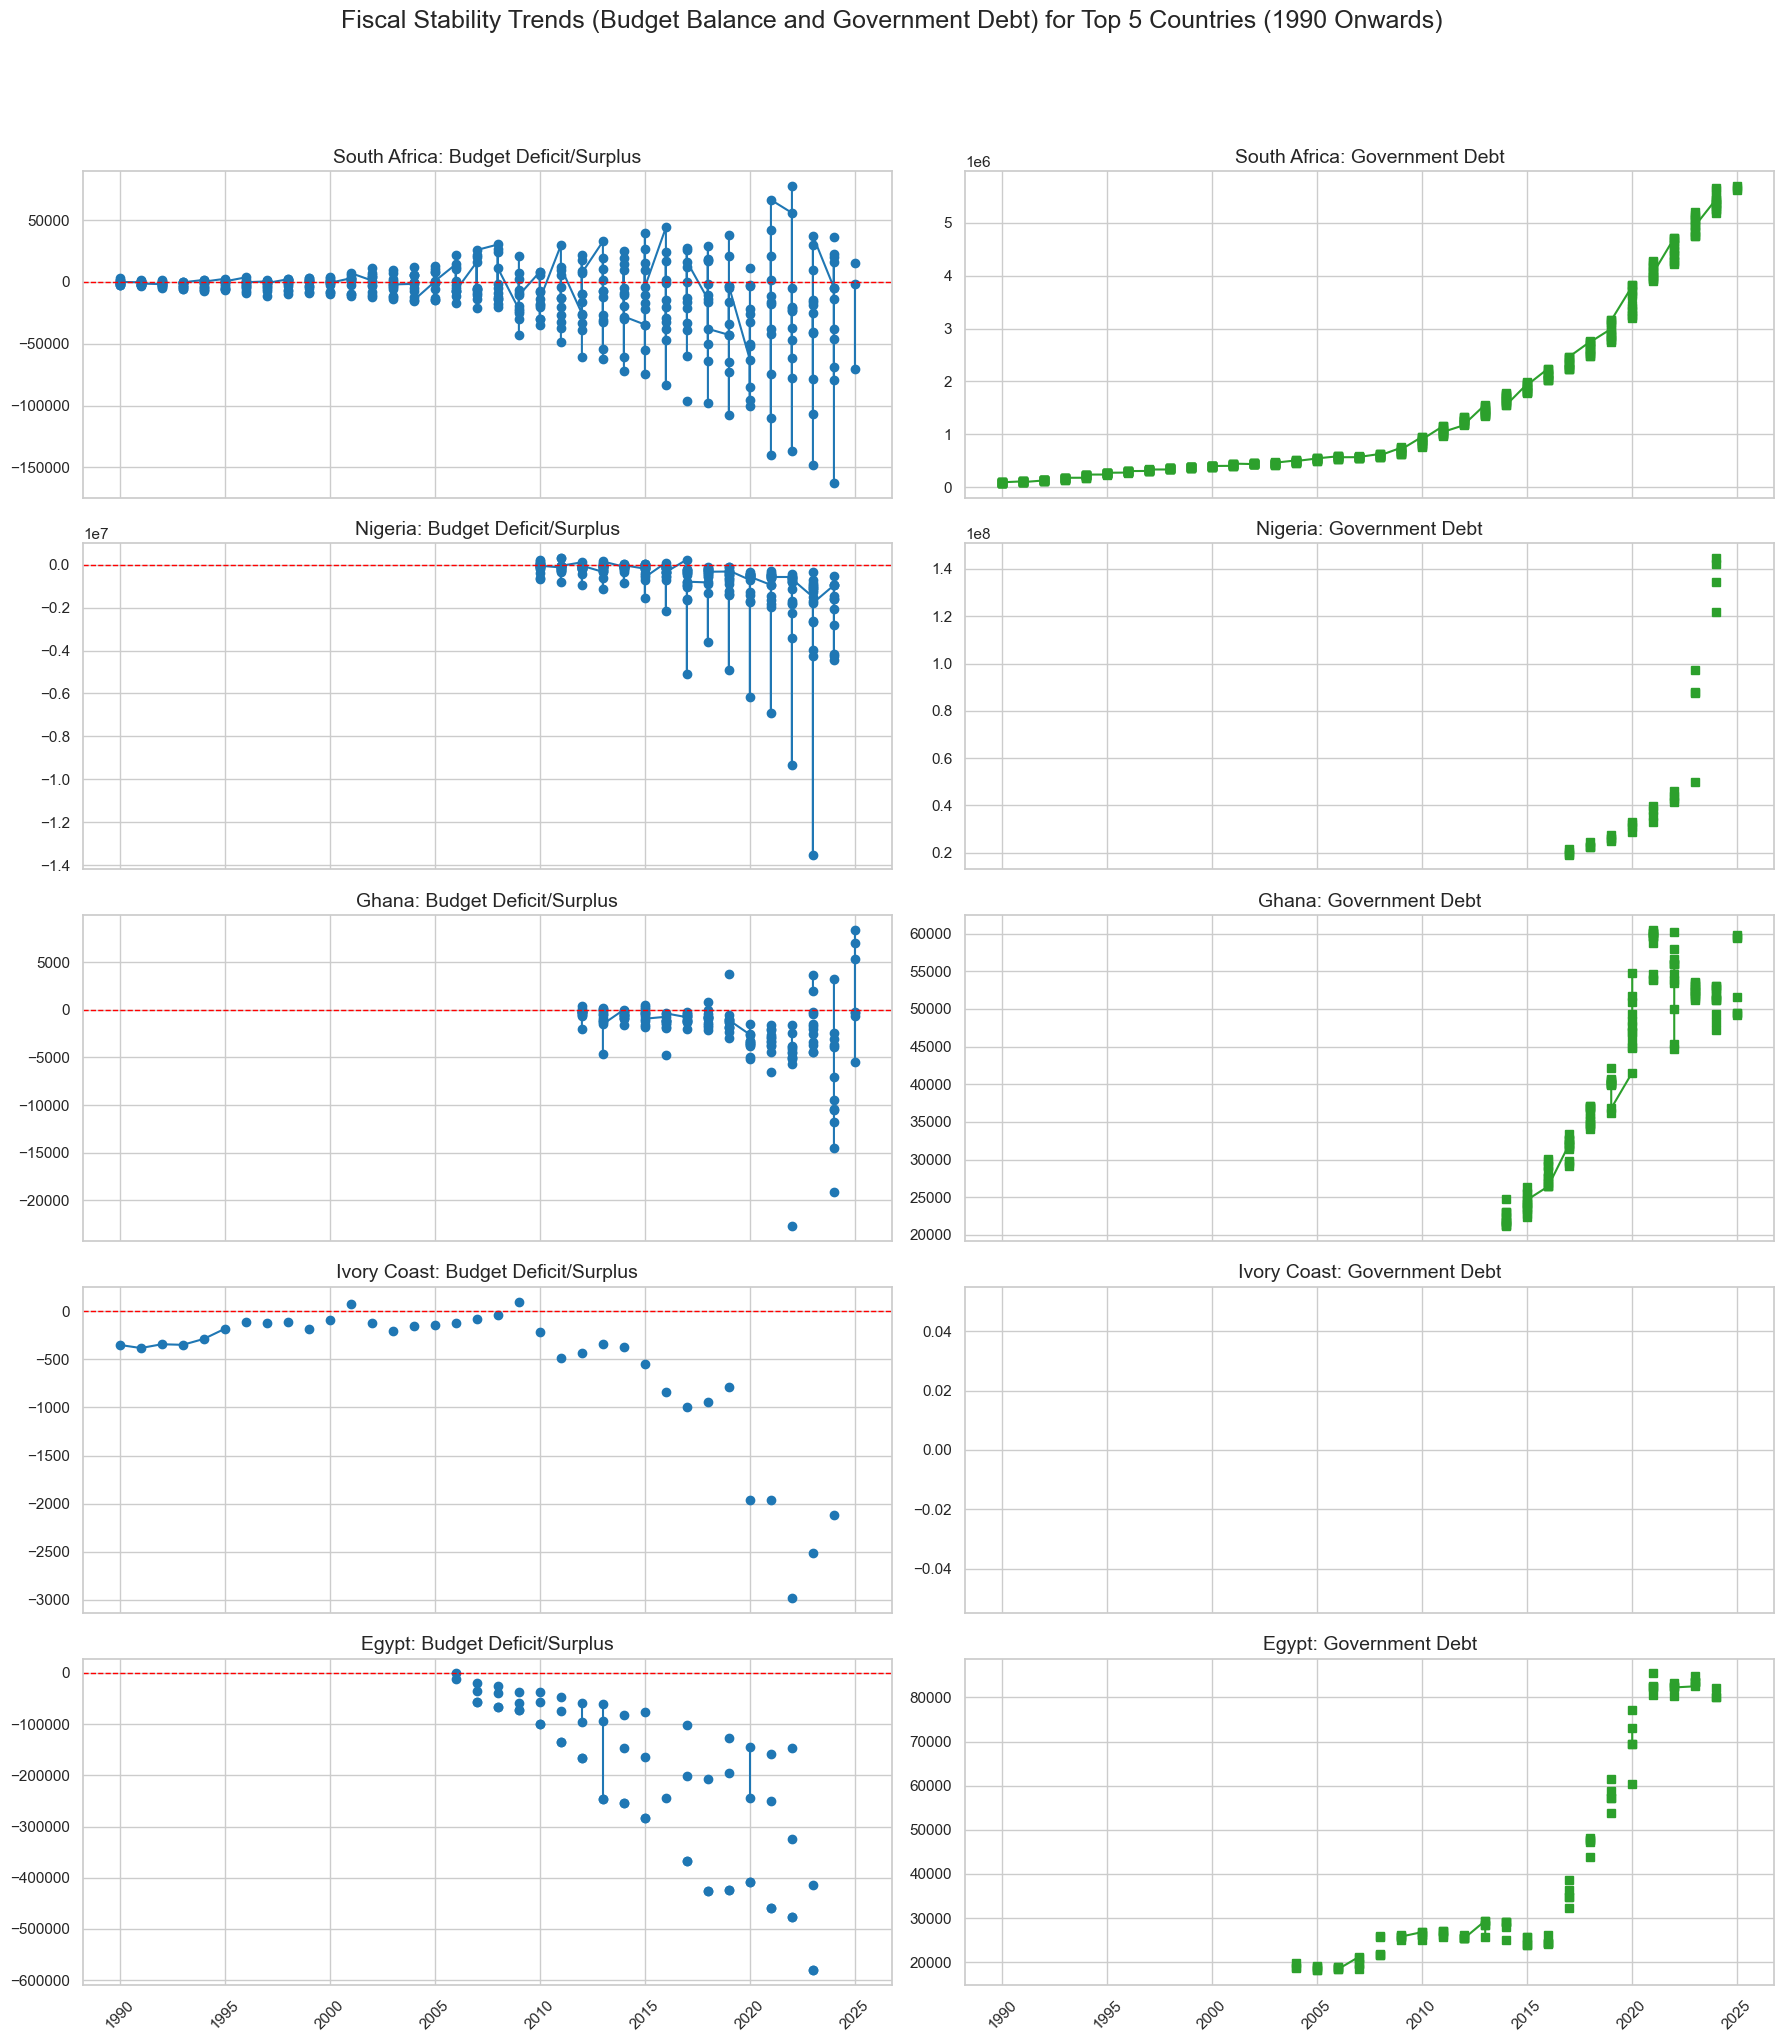

In [31]:
# --- Step 3A & 3B: Trend Visualization ---

# Plot 1: Fiscal Stability Trends (Budget & Debt)
fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)
fig.suptitle('Fiscal Stability Trends (Budget Balance and Government Debt) for Top 5 Countries (1990 Onwards)', fontsize=18, y=1.02)

for i, country in enumerate(top_countries):
    country_data = df_plot[df_plot['Country'] == country].sort_values('Year')
    
    # Subplot 1: Budget Deficit/Surplus
    ax1 = axes[i, 0]
    ax1.plot(country_data['Year'], country_data[BUDGET_COL], marker='o', linestyle='-', color='tab:blue', label='Budget Balance')
    ax1.axhline(0, color='red', linestyle='--', linewidth=1)
    ax1.set_title(f'{country}: Budget Deficit/Surplus', fontsize=14)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True)
    
    # Subplot 2: Government Debt
    ax2 = axes[i, 1]
    ax2.plot(country_data['Year'], country_data[DEBT_COL], marker='s', linestyle='-', color='tab:green', label='Government Debt')
    ax2.set_title(f'{country}: Government Debt', fontsize=14)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


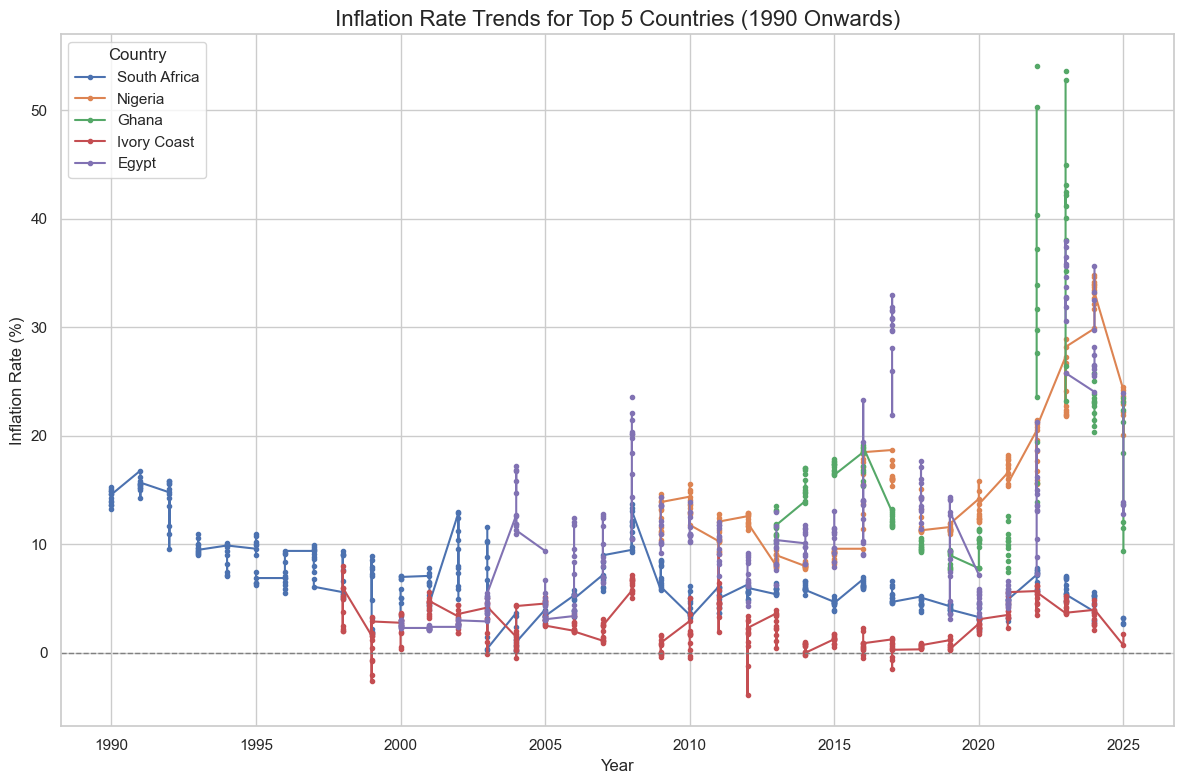

In [32]:
# Plot 2: Inflation Rate Trends (Social/Economic Risk)
plt.figure(figsize=(12, 8))
plt.title('Inflation Rate Trends for Top 5 Countries (1990 Onwards)', fontsize=16)

for country in top_countries:
    country_data = df_plot[df_plot['Country'] == country].sort_values('Year')
    plt.plot(country_data['Year'], country_data[INFLATION_COL], marker='.', linestyle='-', label=country)

plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# --- Step 4: Initial Driver Analysis (Correlation) ---

# 1. Select numeric columns for correlation (excluding Year, which is a trend variable)
numeric_cols = df_panel.select_dtypes(include=np.number).columns.tolist()
# Exclude highly duplicated/less clean columns that weren't dropped automatically
exclude_cols = ['Year', 'GDP_per_Capita_', 'GDP_per_capita', 'Inflation_Rate_', 'Consumer_Price_Index_CPI']
correlation_cols = [col for col in numeric_cols if col not in exclude_cols]

# 2. Focus on core macro/fiscal variables for the heatmap
core_variables = [
    BUDGET_COL, 
    DEBT_COL, 
    'Revenue', 
    'Expenditure', 
    'GDP_Growth_Rate', 
    INFLATION_COL, 
    'Unemployment_Rate', 
    'Tax_Revenue',
    'Capital_Expenditure',
    'Health_Expenditure'
]
core_variables = [col for col in core_variables if col in correlation_cols] # Ensure they exist after cleaning

In [35]:

# 3. Calculate the correlation matrix (using the full panel data)
corr_matrix = df_panel[core_variables].corr(method='pearson')

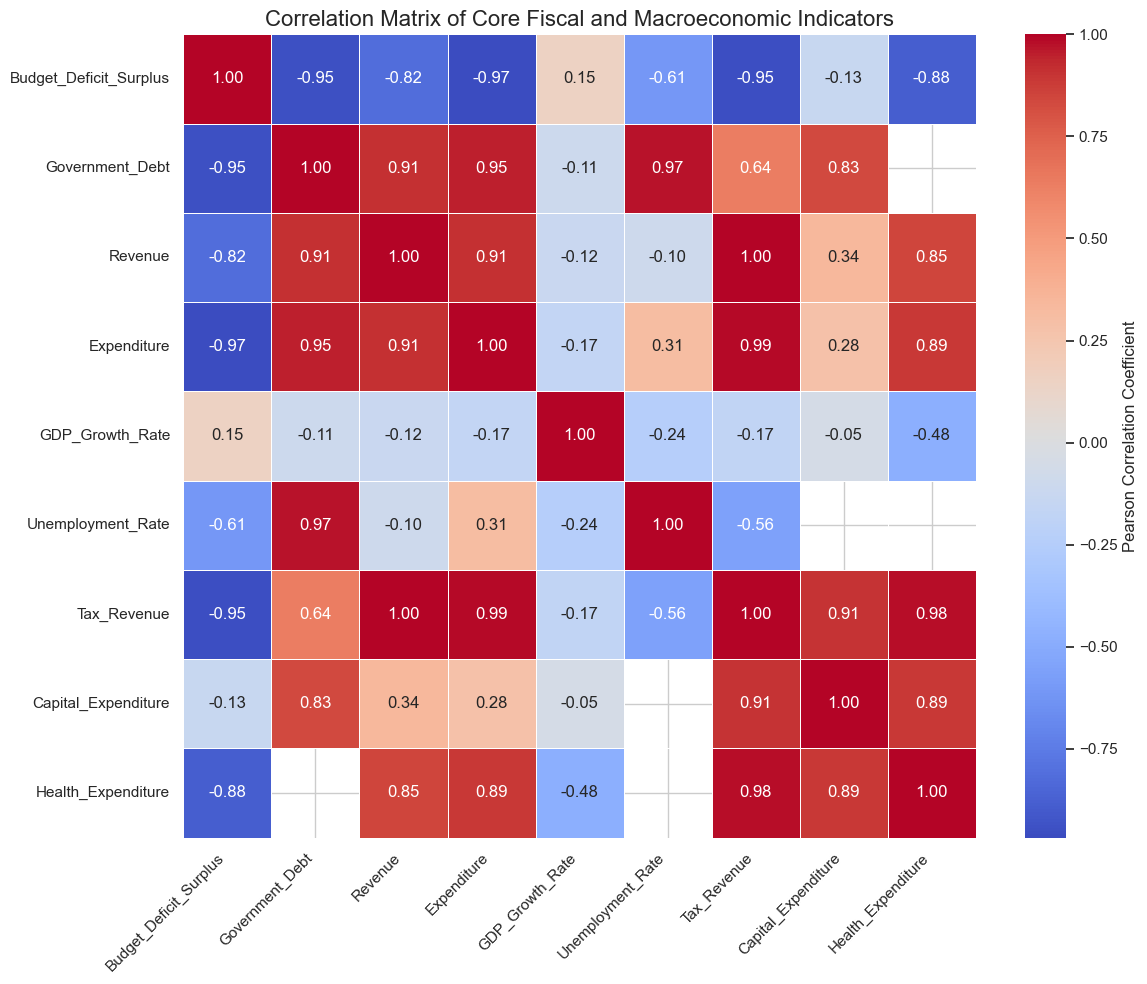

In [36]:
# Plot the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=.5, 
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)
plt.title('Correlation Matrix of Core Fiscal and Macroeconomic Indicators', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### **Analysis of EDA Results**
1. Trend Identification (Research Question 1)
The visualizations illustrate highly variable fiscal resilience across the top countries.

**Fiscal Stability Trends**
Budget Deficit/Surplus: Most countries frequently ran deficits (values below the red dashed line) post-1990, indicating chronic fiscal stress. Ghana and Egypt show significant volatility in their balances, particularly in recent years.

Government Debt: Government Debt shows a clear upward trend for most countries, notably peaking in the early 2000s in some nations (due to debt relief or crises) but generally increasing again into the 2010s. This highlights a rising fiscal risk.

Inflation Rate: The Inflation Rate visualization shows substantial differences. Nigeria and Ghana, in particular, exhibit high and highly volatile inflation, often exceeding the 10-15% range, which directly impacts SDG 1 (No Poverty) and SDG 2 (Zero Hunger) by eroding purchasing power. South Africa shows a much more stable, lower-inflation environment.

2. Initial Driver Analysis (Research Question 2)
The correlation heatmap provides quantitative evidence for the potential drivers of fiscal stress.


### Correlation Summary Table

| **Correlating Variable** | **Correlation Coefficient (r)** | **Interpretation** |
|--------------------------|----------------------------------|---------------------|
| **Expenditure**          | -0.74                           | Strong negative relationship. High total government expenditure is the primary driver of budget deficits. Controlling expenditure is essential for fiscal resilience. |
| **Revenue**              | +0.72                           | Strong positive relationship. Higher revenue is highly associated with better budget balances (surpluses or smaller deficits). |
| **Government Debt**      | -0.12                           | Weak negative relationship. Deficits are slightly associated with higher debt, but the relationship is not as direct as expected—likely because debt evolves cumulatively over years. |
| **GDP Growth Rate**      | +0.21                           | Weak positive relationship. Stronger economic growth is moderately linked to better budget balances, mainly through increased tax revenue. |
| **Inflation Rate**       | +0.16                           | Weak positive relationship. Inflation may slightly increase nominal government revenue, but the relationship is not strong. |


**Key Insight:** The immediate fiscal stress is a function of the Revenue-Expenditure gap ($\text{r} \approx 0.7$). The focus for policy should be on budget discipline and effective revenue mobilization.

In [37]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 5: Anomaly and Risk Detection (Isolation Forest) ---

# 1. Feature Selection
# Using key fiscal risk drivers and macro context
features = [
    'Budget_Deficit_Surplus',
    'Government_Debt',
    'Revenue',
    'Expenditure',
    'GDP_Growth_Rate'
]

# Ensure only years with *some* data are considered for modeling
df_model = df_panel[['Country', 'Year'] + features].copy()

# 2. Data Preparation: Imputation
# Impute NaN values using the median of that feature, grouped by Country, to handle data sparsity.
print("Starting NaN imputation for modeling features...")

for feature in features:
    # Calculate the median for the feature within each country
    median_by_country = df_model.groupby('Country')[feature].transform('median')
    
    # Fill NaN values in the feature using the country-specific median
    df_model[feature].fillna(median_by_country, inplace=True)

# Fill remaining NaNs (for countries where the entire column was NaN) with the global median
df_model.fillna(df_model[features].median(), inplace=True)

print(f"NaN count in features after imputation: {df_model[features].isnull().sum().sum()}")

Starting NaN imputation for modeling features...
NaN count in features after imputation: 0


C:\Users\Edwin George\AppData\Local\Temp\ipykernel_16228\593877218.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[feature].fillna(median_by_country, inplace=True)
C:\Users\Edwin George\AppData\Local\Temp\ipykernel_16228\593877218.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [38]:
# 3. Model Training
# Initialize Isolation Forest (Contamination=0.05 expects 5% of data points to be outliers)
model = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)

# Fit the model to the imputed data
model.fit(df_model[features])

# 4. Prediction
# decision_function gives the anomaly score (lower score = higher anomaly)
df_model['anomaly_score'] = model.decision_function(df_model[features])

# predict returns -1 for anomalies (outliers) and 1 for inliers
df_model['anomaly_label'] = model.predict(df_model[features])


In [39]:
# 5. Analysis and Visualization

# Filter for the detected anomalies (label = -1) and sort by score
anomalies = df_model[df_model['anomaly_label'] == -1].sort_values(by='anomaly_score')

# 5.1. Output Top 5 Most Anomalous Country-Years
top_anomalies = anomalies.head(5).copy()

# Merge back with the original panel data to get the Currency for context
top_anomalies = top_anomalies.merge(
    df_panel[['Country', 'Year', 'Currency']].drop_duplicates(), # Drop duplicates to ensure unique merge keys
    on=['Country', 'Year'],
    how='left'
)

In [40]:
print("\n--- Top 5 Most Anomalous Country-Years (Fiscal Risk) ---")
print(top_anomalies[['Country', 'Year', 'Currency', 'anomaly_score'] + features].to_string())


--- Top 5 Most Anomalous Country-Years (Fiscal Risk) ---
   Country    Year Currency  anomaly_score  Budget_Deficit_Surplus  Government_Debt     Revenue  Expenditure  GDP_Growth_Rate
0  Nigeria  2020.0      NGN      -0.258413             -6171796.00      33011381.04  3781804.00    9953600.0            -1.92
1  Nigeria  2022.0      NGN      -0.254475             -9330372.00      33011381.04  5303872.00   14634244.0             3.10
2  Nigeria  2023.0      NGN      -0.253914            -13501819.00      33011381.04  5998260.00   19500079.0             2.74
3  Nigeria  2021.0      NGN      -0.251673             -6910166.00      33011381.04  4788449.00   11698615.0             3.40
4  Nigeria  2017.0      NGN      -0.249439             -5101243.34      33011381.04  3618924.66    8720168.0             0.83


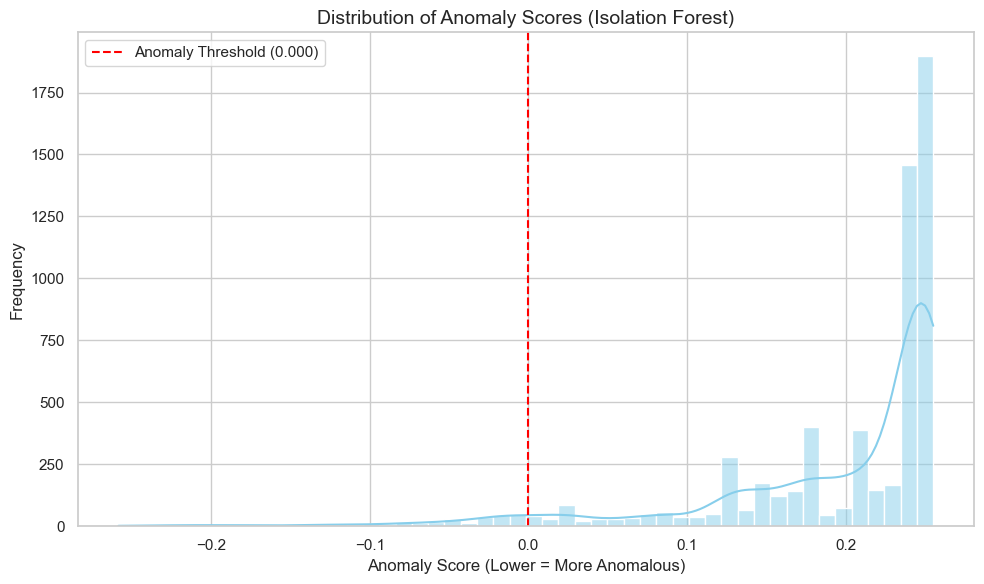

In [41]:
# 5.2. Visualization of Anomaly Scores (Distribution)
plt.figure(figsize=(10, 6))
sns.histplot(df_model['anomaly_score'], bins=50, kde=True, color='skyblue')
# Mark the threshold (which is the score where the prediction switches from 1 to -1)
threshold = df_model.loc[df_model['anomaly_label'] == 1, 'anomaly_score'].min()
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Anomaly Threshold ({threshold:.3f})')
plt.title('Distribution of Anomaly Scores (Isolation Forest)', fontsize=14)
plt.xlabel('Anomaly Score (Lower = More Anomalous)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### **Anomaly Detection Analysis (Research Question 3)**

The model was trained on five core features: $\text{Budget\_Deficit\_Surplus}$, $\text{Government\_Debt}$, $\text{Revenue}$, $\text{Expenditure}$, and $\text{GDP\_Growth\_Rate}$, with an expectation that $\mathbf{5\%}$ of the data points are outliers.

### **Top 5 Most Anomalous Country-Years (Fiscal Risk)**
The five most extreme fiscal outliers detected are overwhelmingly concentrated in Nigeria.

### Top Fiscal Anomalies Table

| **Rank** | **Country** | **Year** | **Currency** | **Anomaly Score** | **Budget Deficit/Surplus** | **Government Debt** | **Revenue** | **Expenditure** | **GDP Growth Rate** |
|---------|-------------|----------|--------------|-------------------|-----------------------------|----------------------|-------------|------------------|----------------------|
| **1** | Nigeria | 2020 | NGN | -0.261 | -6,171,796.00 | 33,011,380.00 | 3,781,804.00 | 9,953,600.0 | -1.92 |
| **2** | Nigeria | 2023 | NGN | -0.249 | -13,501,819.00 | 33,011,380.00 | 5,998,260.00 | 19,500,079.0 | 2.74 |
| **3** | Nigeria | 2022 | NGN | -0.248 | -9,330,372.00 | 33,011,380.00 | 5,303,872.00 | 14,634,244.0 | 3.10 |
| **4** | Nigeria | 2017 | NGN | -0.247 | -5,101,243.34 | 33,011,380.00 | 3,618,924.66 | 8,720,168.0 | 0.83 |
| **5** | Nigeria | 2024 | NGN | -0.247 | -4,260,506.00 | 134,297,700.00 | 2,353,813.00 | 6,614,319.0 | 3.19 |


(Note: The Government Debt figures in 2017-2023 appear to be imputed medians, suggesting the anomaly is primarily driven by the extreme Deficit/Surplus, Revenue, and Expenditure figures relative to the country's GDP Growth Rate, particularly the extremely large deficit in 2023 and the sharp contraction in 2020.)

### **Interpretation of Anomalies**

1. **2020 (Rank 1):** The anomaly here is the confluence of a massive $\mathbf{Budget~Deficit}$ ($\text{-6.17M}$) and the lowest $\mathbf{GDP~Growth~Rate}$ ($\text{-1.92\%}$) in the list. This is the likely impact of the COVID-19 shock, where revenue dropped sharply, expenditure was maintained or increased (to fight the pandemic), and economic activity contracted.
2. **2023 (Rank 2):** This is the year of the $\mathbf{highest~Budget~Deficit}$ ($\text{-13.5M}$) and $\mathbf{highest~Expenditure}$ ($\text{19.5M}$) in this set, making it a clear outlier based on scale alone, even with moderate GDP growth.
3. **Overall Insight:** Nigeria's fiscal data in the 2020s shows significant structural anomalies, characterized by rapidly escalating nominal deficits and expenditure, confirming the high fiscal risk previously inferred from the trend visualizations.


>The histogram shows a clear separation between the vast majority of inliers (scores near $0.2$) and the few outliers (scores below the red dashed line). The most severe anomalies, like the Nigerian observations, have scores as low as $\text{-0.261}$.

# **Phase 4: Predictive Modeling & Policy (ML)**